In [49]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [50]:
df = pd.read_csv('./mymoviedb.csv', engine = 'python')

In [51]:
df.head(2)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...


In [52]:
# Viewing Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


• looks like our dataset has no NaNs! 


• Overview, Original_Language and Poster-Url
wouldn't be so useful during analysis.


• Release_Date column needs to be casted into
date time and to extract only the year value.



In [53]:
# Exploring Genre Column
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

• genres are saperated by commas followed by whitespaces.

In [54]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

• our dataset has no duplicated rows


In [55]:
# Exploring Summary Statistics
df.describe()

,Popularity
count,9827.000000
mean,40.320570
std,108.874308
min,7.100000
25%,16.127500
50%,21.191000
75%,35.174500
max,5083.954000


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [57]:
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'], errors= 'coerce').astype('Int64')
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors = 'coerce').astype(float) 

• Vote_Count and Vote_Average both were object we convert into **int** and __float__

In [58]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9826.0,9826.000000
mean,40.320570,1392.943721,6.439467
std,108.874308,2611.303856,1.129797
min,7.100000,0.0,0.000000
25%,16.127500,146.0,5.900000
50%,21.191000,444.0,6.500000
75%,35.174500,1376.0,7.100000
max,5083.954000,31077.0,10.000000


In [59]:
df.dtypes

Release_Date          object
Title                 object
Overview              object
Popularity           float64
Vote_Count             Int64
Vote_Average         float64
Original_Language     object
Genre                 object
Poster_Url            object
dtype: object

• __Exploration Summary__

• We have a dataframe consisting of **9827** rows and **9** columns.  
• Our dataset looks a bit tidy with **no NaNs** nor duplicated values.  
• Overview, Original_Languege and Poster-Url wouldn't be so useful during analysis.  
• Vote_Average bettter be categorised for proper analysis.  

In [60]:
# Data CLeaning

Casting Released_Date column and extracting year values.

In [61]:
# Casting Column
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors = 'coerce')
print(df["Release_Date"].dtypes)

datetime64[ns]


In [62]:
print(df['Release_Date'].isna().sum())


10


In [63]:
df['Release_Date'] = df['Release_Date'].dt.year
df['Release_Date'].dtypes

dtype('float64')

In [64]:
# Convert Release_Date column from float to int
df['Release_Date'] = df['Release_Date'].astype('Int64')

# confirm changes
print(df['Release_Date'].head())
print(df.dtypes)


0    2021
1    2022
2    2022
3    2021
4    2021
Name: Release_Date, dtype: Int64
Release_Date           Int64
Title                 object
Overview              object
Popularity           float64
Vote_Count             Int64
Vote_Average         float64
Original_Language     object
Genre                 object
Poster_Url            object
dtype: object


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   Int64  
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9826 non-null   Int64  
 5   Vote_Average       9826 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: Int64(2), float64(2), object(5)
memory usage: 711.0+ KB


In [66]:
df.head(2)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...


In [67]:
# making list of column to be dropped
cols = ['Overview', 'Original_Language', 'Poster_Url']

In [68]:
# dropping columns and confirming changes
df.drop(cols ,axis = 1, inplace = True)

In [69]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


__categorizing Vote_Average column__  
We would cut the Vote_Average values and make 4 categories:  
popular,average,below_avg,not_popular to describe it more using catigorize_col() function
provided above

In [70]:
labels = ['not_popular', 'below_avg', 'average', 'popular']
# Categorizing Vote_Average based on quartiles
df['Vote_Average'] = pd.qcut(df['Vote_Average'], q=4, labels=labels)

# check unique labels
print(df['Vote_Average'].unique())

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']


In [71]:
df.head(2)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"


In [72]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2567
popular        2450
average        2411
below_avg      2398
Name: count, dtype: int64

In [73]:
# Dropping Nans
df.dropna(inplace= True)

In [74]:
# Confirming
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [75]:
df.head(3)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller


__We'd split Genres into a list and then
explode our dataframe to have only one
Genre per row for each movie__

In [76]:
# Split the string into lists
df['Genre'] = df['Genre'].str.split(', ')

In [77]:
# Explode the list
df = df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [78]:
# casting column into category
df['Genre'] = df['Genre'].astype('category')
# confirming changes
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [79]:
df.nunique()

Release_Date     102
Title           9512
Popularity      8159
Vote_Count      3266
Vote_Average       4
Genre             19
dtype: int64

Now that our dataset is clean, we are left with a total of 6 columns and 25792
rows to dig into during our analysis

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25792 entries, 0 to 25791
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25792 non-null  Int64   
 1   Title         25792 non-null  object  
 2   Popularity    25792 non-null  float64 
 3   Vote_Count    25792 non-null  Int64   
 4   Vote_Average  25792 non-null  category
 5   Genre         25792 non-null  category
dtypes: Int64(2), category(2), float64(1), object(1)
memory usage: 907.8+ KB


## Data Visualization

Here, we'd use Matplotlib and Seaborn for making some informative visuals to gain
insights about our data.

In [81]:
# Setting up Seaborn Configurations
sns.set_style('whitegrid')

### Q1: What is the most frequent genre in the dataset?

In [82]:
# Showing stats on Genre Column
df['Genre'].describe()

count     25792
unique       19
top       Drama
freq       3744
Name: Genre, dtype: object

Text(0.5, 1.0, 'Genre Column Distribution')

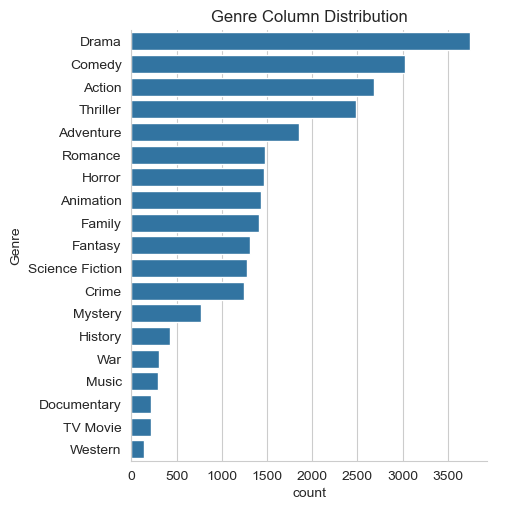

In [83]:
sns.catplot( y = 'Genre', data = df, kind = 'count', order = df['Genre'].value_counts().index)
plt.title('Genre Column Distribution')

• We can notice from the above visual that __Drama__ genre is the most frequent genre
in our dataset and has appeared more than 14% of the times among 19 other
genres

### Q2: What Genres has highest votes ?

Text(0.5, 1.0, 'Vote Distribution')

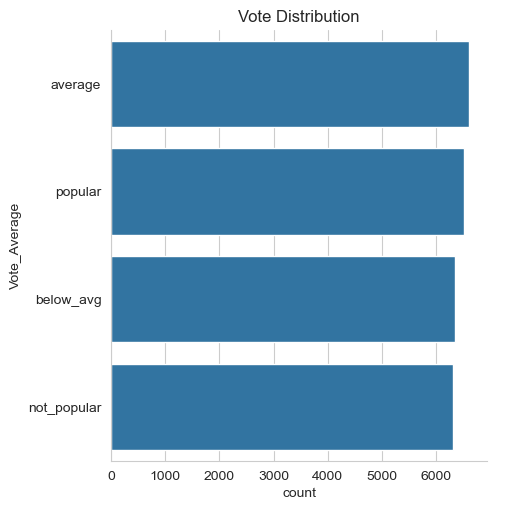

In [84]:
# visualizing vote_average column
sns.catplot(y = 'Vote_Average', data = df, kind = 'count', order = df['Vote_Average'].value_counts().index)
plt.title('Vote Distribution')

### Q3: What movie got the highest __Popularity__ ? what's its __Genre__ ?

In [85]:
# Checking Max Populartity in Dataset
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


### Q4: What movie got the lowest __Popularity__? what's its __Genre__?

In [86]:
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25786,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25787,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25788,2021,The United States vs. Billie Holiday,13.354,152,average,History
25789,1984,Threads,13.354,186,popular,War
25790,1984,Threads,13.354,186,popular,Drama
25791,1984,Threads,13.354,186,popular,Science Fiction


### Q5: Which year has the most filmmed movies?

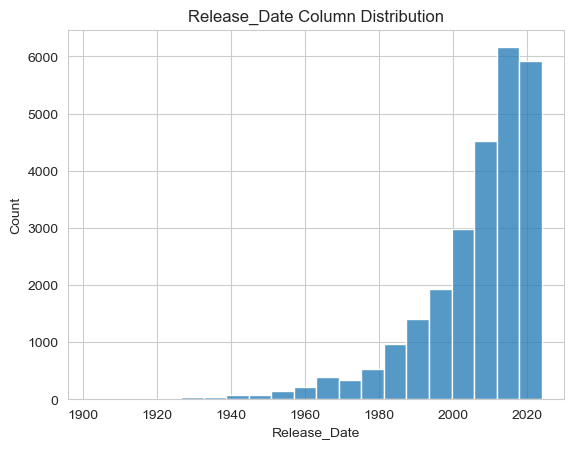

In [89]:
sns.histplot(data=df, x='Release_Date', bins=20)
plt.title('Release_Date Column Distribution')
plt.show()

### Conclusion

### Q1: What is the most frequent genre in the dataset?
##### Ans: Drama genre is the most frequent genre in our dataset and has appeared more than 14% of the times among 19 other genres.

### Q2: What genres has highest votes ?
##### Ans: We have 25.5% of our dataset with popular vote (6520 rows). Drama again gets the highest popularity among fans by being having more than 18.5% of movies popularities.

### Q3: What movie got the highest popularity ? what's its genre ?
##### Ans: Spider-Man: No Way Home has the highest popularity rate in our dataset and it has genres of Action , Adventure and Sience Fiction .

### Q3: What movie got the lowest popularity ? what's its genre ?
##### Ans: The united states, thread' has the highest lowest rate in our dataset and it has genres of music , drama , 'war', 'sci-fi' and history`.

### Q4: Which year has the most filmmed movies?
##### Ans: Year 2020 has the highest filmming rate in our dataset.